## Data Cleaning

In [31]:
# cleaning
# imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
#create df
df = pd.read_csv("spx_eod_202301.txt")
pd.set_option('display.max_columns', None)
# drops columns that we may not need
df = df.drop(columns=["[QUOTE_UNIXTIME]", " [QUOTE_READTIME]", " [QUOTE_DATE]", " [EXPIRE_DATE]", " [EXPIRE_UNIX]"])
# rename for easier use in future
df = df.rename(columns={
    ' [QUOTE_TIME_HOURS]' : "Quote_Time_Hours",
    ' [UNDERLYING_LAST]' : "Underlying_Last",
    ' [DTE]' : "DTE",
    ' [C_DELTA]' : "C_Delta",
    ' [C_GAMMA]' : "C_Gamma", 
    ' [C_VEGA]' : "C_Vega", 
    ' [C_THETA]' : "C_Theta",
    ' [C_RHO]' : "C_Rho", 
    ' [C_IV]' : "C_IV",
    ' [C_VOLUME]' : "C_Volume",
    ' [C_LAST]' : "C_Last", 
    ' [C_SIZE]' : "C_Size", 
    ' [C_BID]' : "C_Bid", 
    ' [C_ASK]' : "C_Ask",
    ' [STRIKE]' : "Strike", 
    ' [P_BID]' : "P_Bid",
    ' [P_ASK]' : "P_Ask",
    ' [P_SIZE]' : "P_Size", 
    ' [P_LAST]' : "P_Last",
    ' [P_DELTA]' : "P_Delta", 
    ' [P_GAMMA]' : "P_Gamma", 
    ' [P_VEGA]' : "P_Vega", 
    ' [P_THETA]' : "P_Theta", 
    ' [P_RHO]' : "P_Rho",
    ' [P_IV]' : "P_IV", 
    ' [P_VOLUME]' : "P_Volume", 
    ' [STRIKE_DISTANCE]' : "Strike_Distance",
    ' [STRIKE_DISTANCE_PCT]' : "Strike_Distance_PCT"
})
df = df.drop(columns=["C_Delta", "C_Gamma", "C_Vega", "C_Theta", "C_Rho", "P_Delta", "P_Gamma", "P_Vega", "P_Theta", "P_Rho"])
# turn " " in implied volatility columns into missing values and then drop
df["P_IV"] = df["P_IV"].replace(" ", np.nan)
df["C_IV"] = df["C_IV"].replace(" ", np.nan)
df = df.dropna(subset=["C_IV", "P_IV"])
# convert string into float
df["P_IV"] = df["P_IV"].astype(float)
df["C_IV"] = df["C_IV"].astype(float)
# create new columns, separate the size into bid and ask, convert to int
df["C_Bid_Size"] = df["C_Size"].str.split("x").str.get(0).astype(float)
df["C_Ask_Size"] = df["C_Size"].str.split("x").str.get(1).astype(float)
df["P_Bid_Size"] = df["P_Size"].str.split("x").str.get(0).astype(float)
df["P_Ask_Size"] = df["P_Size"].str.split("x").str.get(1).astype(float)
# since new columns were made we can drop original C_Size and P_Size
df = df.drop(columns = ["C_Size", "P_Size"])
df["C_Mid_Price"] = (df["C_Bid"] + df["C_Ask"]) / 2 
df["P_Mid_Price"] = (df["P_Bid"] + df["P_Ask"]) / 2 
# replace missing with zero and convert to float value 
df["C_Volume"] = df["C_Volume"].replace(" ", 0)
df["P_Volume"] = df["P_Volume"].replace(" ", 0)
df["C_Volume"] = df["C_Volume"].astype(float)
df["P_Volume"] = df["P_Volume"].astype(float)

## Call IV Random Forest Model

In [28]:
#Fit the model
x = df[["Underlying_Last", "DTE", "Strike", "C_Volume", "Strike_Distance", "Strike_Distance_PCT", "C_Mid_Price"]]
y = df["C_IV"]
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(x_train, y_train)
y_test_pred = rf.predict(x_test)

In [29]:
# Model evaluation
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

MAE: 0.023673420466909244
R²: 0.7796202944930355
RMSE: 0.22126641582648698


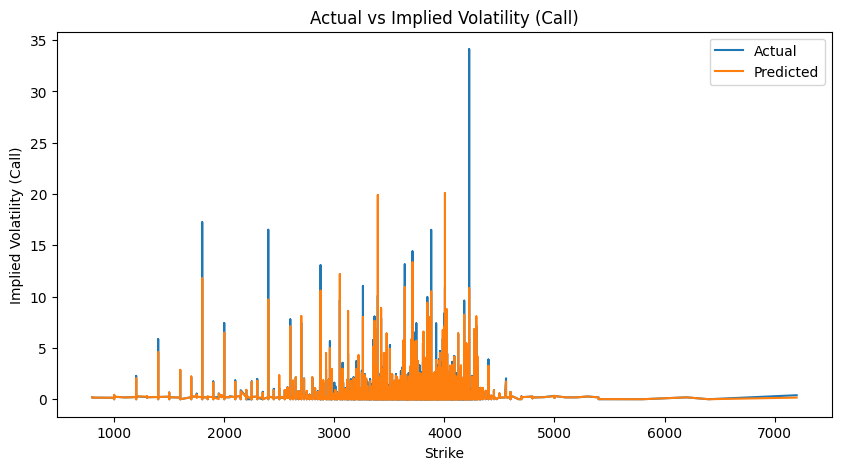

In [38]:
x_sorted = x_test.sort_values("Strike")
plt.figure(figsize=(10, 5))
plt.plot(x_sorted["Strike"], y_test, label="Actual")
plt.plot(x_sorted["Strike"], y_test_pred, label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Implied Volatility (Call)")
plt.legend()
plt.show()

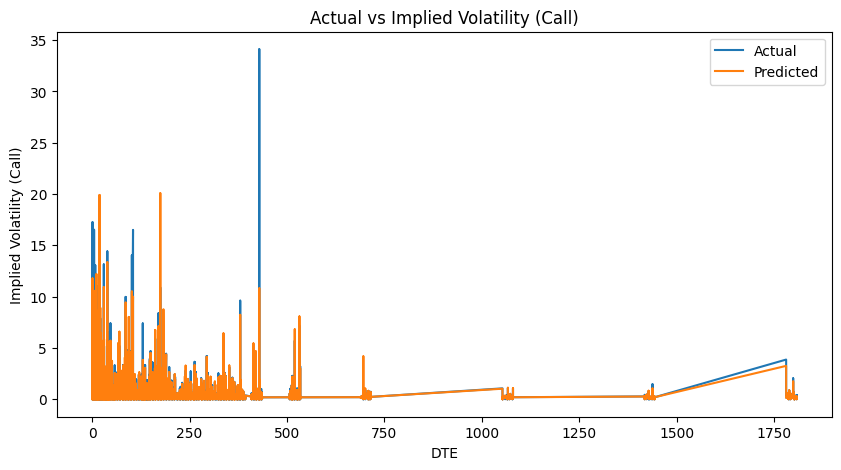

In [39]:
x_sorted = x_test.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(x_sorted["DTE"], y_test, label="Actual")
plt.plot(x_sorted["DTE"], y_test_pred, label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Implied Volatility (Call)")
plt.legend()
plt.show()

## Call IV XGB Model

In [36]:
a = df[["Underlying_Last", "DTE", "Strike", "C_Volume", "Strike_Distance", "Strike_Distance_PCT", "C_Mid_Price"]]
b = df["C_IV"]
a_train, a_test, b_train, b_test = train_test_split(
    a,
    b,
    test_size=0.25,
    random_state=42
)
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.75,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(a_train, b_train)
b_test_pred = xgb.predict(a_test)

In [37]:
print("MAE:", mean_absolute_error(b_test, b_test_pred))
print("R²:", r2_score(b_test, b_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(b_test, b_test_pred)))

MAE: 0.05242621930360189
R²: 0.8672254520360957
RMSE: 0.1717461924075314


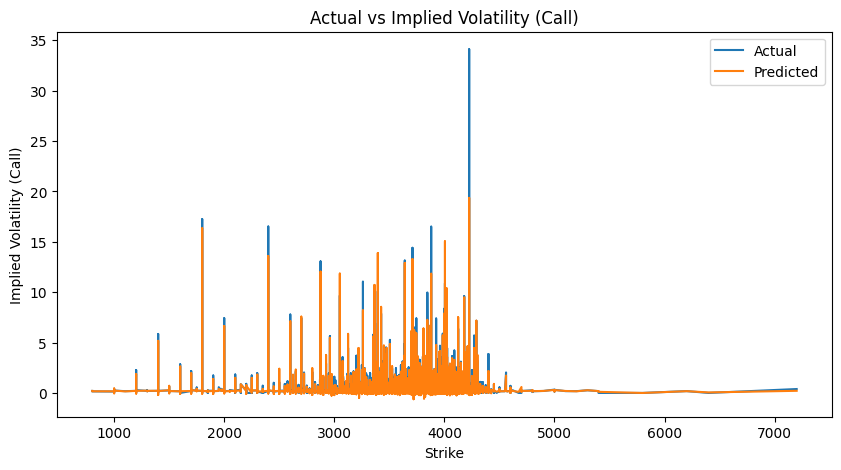

In [40]:
a_sorted = a_test.sort_values("Strike")
plt.figure(figsize=(10, 5))
plt.plot(a_sorted["Strike"], b_test, label="Actual")
plt.plot(a_sorted["Strike"], b_test_pred, label="Predicted")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Implied Volatility (Call)")
plt.legend()
plt.show()

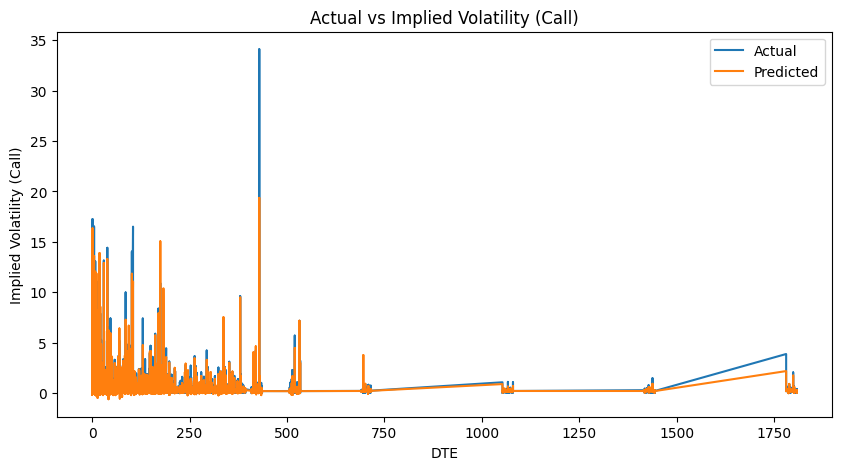

In [41]:
a_sorted = a_test.sort_values("DTE")
plt.figure(figsize=(10, 5))
plt.plot(a_sorted["DTE"], b_test, label="Actual")
plt.plot(a_sorted["DTE"], b_test_pred, label="Predicted")
plt.xlabel("DTE")
plt.ylabel("Implied Volatility (Call)")
plt.title("Actual vs Implied Volatility (Call)")
plt.legend()
plt.show()